# Bayesian Learning Pipeline for Client Personas

notebook combines Bayesian Gaussian Mixture modeling with Learning Vector Quantization (LVQ) to identify and interpret distinct customer personas from banking client data.

## Objectives

- Prepare and encode mixed numerical/categorical client data.
- Discover latent persona clusters using Bayesian Gaussian Mixture.
- Build business-readable cluster profiles.
- Train and interpret an LVQ model to obtain representative class prototypes.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.mixture import BayesianGaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklvq.models import GLVQ

plt.rcParams["figure.dpi"] = 150
plt.style.use("ggplot")

## 1) Data Loading and Preprocessing

We keep the preprocessing logic explicit because clustering quality depends heavily on feature treatment.

- Categorical variables are one-hot encoded.
- Continuous variables are standardized with `StandardScaler` for Bayesian Gaussian Mixture.


In [2]:
mapping_dicts = {
    "Gender": {"0": "Male", "1": "Female", "0.0": "Male", "1.0": "Female"},
    "Job": {
        "1": "Unemployed",
        "2": "Employee/Worker",
        "3": "Manager/Executive",
        "4": "Entrepreneur/Freelancer",
        "5": "Retired",
    },
    "Area": {"1": "Nord", "2": "Centro", "3": "Sud/Isole"},
    "CitySize": {"1": "Small town", "2": "Medium-sized city", "3": "Large city"},
    "Investments": {
        "1": "No investments",
        "2": "Mostly lump sum",
        "3": "Capital accumulation",
    },
}

# Load data and remove the ID key because it has no clustering signal.
data = pd.read_excel("./Dataset1_BankClients.xlsx")
data = data.drop(columns=["ID"])

categorical_columns = ["Gender", "Job", "Area", "CitySize", "Investments"]

In [3]:
# One-hot encode categorical features.
data_encoded = pd.get_dummies(data, columns=categorical_columns, dtype=int)

# Continuous numeric columns from original raw data (excluding coded categoricals).
continuous_columns = [
    col
    for col in data.select_dtypes(include=["number"]).columns
    if col not in categorical_columns
]

# Standard scaling for Bayesian Gaussian Mixture.
scaler_1 = StandardScaler()
data_scaled_bayesian = data_encoded.copy()
data_scaled_bayesian[continuous_columns] = scaler_1.fit_transform(
    data_scaled_bayesian[continuous_columns]
)

data_scaled_bayesian.head()

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,-1.670489,1.073958,0.433001,0.575951,-0.748623,1.235010,-0.617483,0.800065,-0.004974,0.657254,...,0,0,1,0,0,1,0,1,0,0
1,-0.616420,-1.057475,1.327150,1.565361,1.346014,1.864025,-0.298538,2.017936,1.025961,1.806599,...,0,0,1,0,0,0,1,0,0,1
2,-1.028882,-0.346997,1.648189,1.487387,0.052818,-0.134078,0.370969,1.041585,0.495903,1.323776,...,0,1,0,0,0,1,0,0,0,1
3,0.300162,0.363481,-0.173947,-0.727400,0.764487,-0.095609,-0.318441,0.292808,0.346059,-0.578159,...,0,1,0,0,0,1,0,0,1,0
4,-1.258027,-1.057475,1.083924,0.709348,1.797800,1.847244,1.179065,0.853386,0.859074,2.017167,...,0,1,0,0,0,0,1,0,1,0


## 2) Bayesian Gaussian Mixture for Persona Discovery

We fit a Dirichlet Process Bayesian GMM with an upper bound on components, then keep only components with meaningful weight (greater than 5%). This acts as automatic model complexity control.


In [4]:
max_clusters = 15

bgm = BayesianGaussianMixture(
    n_components=max_clusters,
    covariance_type="full",
    weight_concentration_prior_type="dirichlet_process",
    random_state=42,
    max_iter=1000,
    init_params="kmeans",
)

bgm.fit(data_scaled_bayesian)

raw_labels = bgm.predict(data_scaled_bayesian)
raw_weights = pd.Series(bgm.weights_, name="weight")

weight_threshold = 0.05
active_components = raw_weights[raw_weights > weight_threshold].index.tolist()
active_mask = pd.Series(raw_labels).isin(active_components)

data_persona = data_scaled_bayesian.loc[active_mask].copy()
data_persona["persona_cluster"] = pd.Series(raw_labels)[active_mask].values

# Remap sparse component IDs to consecutive persona labels.
cluster_remap = {old: new for new, old in enumerate(sorted(active_components))}
data_persona["persona_cluster"] = data_persona["persona_cluster"].map(cluster_remap)

persona_summary = (
    data_persona["persona_cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("share")
    .to_frame()
)
persona_summary["count"] = (
    data_persona["persona_cluster"].value_counts().sort_index().values
)

print(f"Max components (K): {max_clusters}")
print(f"Retained persona frameworks: {len(active_components)}")
print(f"Active original component IDs: {sorted(active_components)}")
persona_summary

Max components (K): 15
Retained persona frameworks: 5
Active original component IDs: [1, 2, 4, 11, 13]


,share,count
persona_cluster,,
0,0.513465,2288
1,0.157989,704
2,0.080117,357
3,0.152154,678
4,0.096275,429


In [5]:
# Persist the clustered dataset for downstream LVQ modeling.
data_persona.to_excel("result/bayesian-clustered-bankClients.xlsx", index=False)
data_persona.head()

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3,persona_cluster
0,-1.670489,1.073958,0.433001,0.575951,-0.748623,1.235010,-0.617483,0.800065,-0.004974,0.657254,...,0,1,0,0,1,0,1,0,0,1
1,-0.616420,-1.057475,1.327150,1.565361,1.346014,1.864025,-0.298538,2.017936,1.025961,1.806599,...,0,1,0,0,0,1,0,0,1,3
2,-1.028882,-0.346997,1.648189,1.487387,0.052818,-0.134078,0.370969,1.041585,0.495903,1.323776,...,1,0,0,0,1,0,0,0,1,3
3,0.300162,0.363481,-0.173947,-0.727400,0.764487,-0.095609,-0.318441,0.292808,0.346059,-0.578159,...,1,0,0,0,1,0,0,1,0,0
4,-1.258027,-1.057475,1.083924,0.709348,1.797800,1.847244,1.179065,0.853386,0.859074,2.017167,...,1,0,0,0,0,1,0,1,0,3


## 3) Qualitative Persona Overlay

To make clusters actionable for business stakeholders, we convert centroids back to interpretable attributes:

- Continuous means are inverse-transformed to original units.
- Dominant categorical values are recovered from one-hot proportions.
- Confidence tags indicate whether each dominant category is clearly represented.


In [6]:
cluster_scaled_means = data_persona.groupby("persona_cluster").mean(numeric_only=True)

continuous_scaled = cluster_scaled_means[continuous_columns]
continuous_original = pd.DataFrame(
    scaler_1.inverse_transform(continuous_scaled),
    columns=continuous_columns,
    index=continuous_scaled.index,
)

categorical_profile = pd.DataFrame(index=cluster_scaled_means.index)
for col in categorical_columns:
    onehot_cols = [c for c in cluster_scaled_means.columns if c.startswith(f"{col}_")]
    if not onehot_cols:
        continue

    proportions = cluster_scaled_means[onehot_cols]
    dominant_onehot = proportions.idxmax(axis=1)
    dominant_value_raw = dominant_onehot.str.replace(f"{col}_", "", regex=False)
    dominant_value_mapped = dominant_value_raw.map(
        lambda x: mapping_dicts.get(col, {}).get(str(x), x)
    )

    categorical_profile[f"{col}_dominant"] = dominant_value_mapped
    categorical_profile[f"{col}_share"] = proportions.max(axis=1)

business_profile = continuous_original.join(categorical_profile)
cluster_count = data_persona["persona_cluster"].value_counts().sort_index()
cluster_share = cluster_count / cluster_count.sum()
business_profile["persona_size"] = (
    cluster_count.reindex(business_profile.index).fillna(0).astype(int)
)
business_profile["persona_share"] = cluster_share.reindex(
    business_profile.index
).fillna(0.0)


def share_confidence_tag(v: float) -> str:
    if v >= 0.75:
        return "High confidence"
    if v >= 0.55:
        return "Medium confidence"
    return "Low confidence"


for col in categorical_columns:
    share_col = f"{col}_share"
    if share_col in business_profile.columns:
        business_profile[f"{col}_confidence"] = business_profile[share_col].apply(
            share_confidence_tag
        )

business_profile

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,CitySize_share,Investments_dominant,Investments_share,persona_size,persona_share,Gender_confidence,Job_confidence,Area_confidence,CitySize_confidence,Investments_confidence
persona_cluster,,,,,,,,,,,,,,,,,,,,,
0,58.723776,2.847902,0.565544,0.572918,0.489046,0.503810,0.545017,0.513323,0.575611,0.443802,...,0.502622,Capital accumulation,0.501311,2288,0.513465,Low confidence,High confidence,Medium confidence,Low confidence,Low confidence
1,53.012784,2.507102,0.599019,0.587074,0.451639,0.517997,0.563484,0.589552,0.582161,0.523466,...,0.663352,Capital accumulation,0.443182,704,0.157989,Medium confidence,Medium confidence,High confidence,Medium confidence,Low confidence
2,80.927171,2.058824,0.368339,0.363737,0.116901,0.332793,0.619582,0.310718,0.645335,0.263214,...,0.481793,Mostly lump sum,0.453782,357,0.080117,High confidence,High confidence,Medium confidence,Low confidence,Low confidence
3,52.346608,2.085546,0.828021,0.834344,0.593841,0.756932,0.671799,0.784804,0.801353,0.709767,...,0.730088,Capital accumulation,0.544248,678,0.152154,Medium confidence,High confidence,High confidence,Medium confidence,Low confidence
4,81.769231,2.130536,0.348933,0.357028,0.113540,0.346101,0.631440,0.328163,0.650396,0.254463,...,0.477855,Mostly lump sum,0.573427,429,0.096275,High confidence,High confidence,Medium confidence,Low confidence,Medium confidence


## Final Clustering Result (5 Personas)

The final clustering solution identifies **5 customer personas** (total \(N = 4456\)).

### Persona 0: Mature Mainstream Working Families

- **Size:** 2288 clients (**51.35%**)
- **Profile:** Average age around 59, medium family size, medium income/wealth, moderate debt.
- **Behavior:** Balanced financial behavior, moderate digital usage, moderate financial education.
- **Dominant traits:** Female, Employee/Worker, Nord, Medium-sized city.
- **Investment style:** Capital accumulation.

### Persona 1: Urban Middle-Aged Female Accumulators

- **Size:** 704 clients (**15.80%**)
- **Profile:** Around 53 years old, smaller families, slightly higher income/wealth than Persona 0.
- **Behavior:** Higher digital adoption and more active lifestyle.
- **Dominant traits:** Female, mostly Employee/Worker, strongly Nord, Large city.
- **Investment style:** Capital accumulation.

### Persona 2: Elderly Male Retirees (Conservative)

- **Size:** 357 clients (**8.01%**)
- **Profile:** Oldest segment (about 81), small households, low income/wealth, very low debt.
- **Behavior:** Low digital engagement, low lifestyle/luxury orientation.
- **Dominant traits:** Male, Retired, Nord, Medium-sized city.
- **Investment style:** Mostly lump sum.

### Persona 3: Affluent Digital Professionals

- **Size:** 678 clients (**15.22%**)
- **Profile:** Around 52 years old, highest income/wealth among all clusters.
- **Behavior:** Highest financial education, strongest digital adoption, high ESG and lifestyle/luxury orientation.
- **Dominant traits:** Mostly Male, Employee/Worker, strongly Nord, Large city.
- **Investment style:** Capital accumulation.

### Persona 4: Elderly Female Retirees (Low-Intensity Banking)

- **Size:** 429 clients (**9.63%**)
- **Profile:** About 82 years old, low income/wealth, low debt.
- **Behavior:** Low digital activity and low lifestyle/luxury propensity.
- **Dominant traits:** Female, Retired, Nord, Medium-sized city.
- **Investment style:** Mostly lump sum.

### Overall Interpretation

The clustering is mainly driven by:

1. **Life stage** (working-age vs retired)
2. **Economic capacity** (mass market vs affluent)
3. **Behavioral engagement** (digital/active vs low-intensity)
4. **Retired segment split by gender** (Persona 2 vs Persona 4)

This segmentation provides a strong basis for targeted strategies in advisory, digital engagement, and product personalization.


## 4) LVQ Modeling on Persona Labels

The LVQ stage provides prototype vectors per persona. These prototypes are useful to summarize each segment and to visualize class geometry.


In [7]:
df = pd.read_excel("./result/bayesian-clustered-bankClients.xlsx")
X = df.drop(columns=["persona_cluster"])
y = df["persona_cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

lvq = GLVQ(
    prototype_init="class-conditional-mean",
    prototype_n_per_class=1,
    random_state=42,
    solver_type="steepest-gradient-descent",
    solver_params={"max_runs": 100},
)
lvq.fit(X_train, y_train)

y_pred_test = lvq.predict(X_test)
y_pred_train = lvq.predict(X_train)

print("Model Evaluation")
print(f"Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nClassification Report")
print(classification_report(y_test, y_pred_test))

Model Evaluation
Training accuracy: 0.8121
Testing accuracy: 0.8197

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       687
           1       1.00      0.07      0.13       211
           2       0.99      0.91      0.95       107
           3       0.80      1.00      0.89       203
           4       0.99      0.95      0.97       129

    accuracy                           0.82      1337
   macro avg       0.91      0.78      0.76      1337
weighted avg       0.85      0.82      0.77      1337



In [8]:
prototypes = lvq.prototypes_
prototype_labels = getattr(lvq, "prototypes_labels_", np.sort(np.unique(y_train)))

if hasattr(X_train, "columns"):
    feature_names = list(X_train.columns)
else:
    feature_names = [f"feature_{i}" for i in range(prototypes.shape[1])]

if len(feature_names) != prototypes.shape[1]:
    feature_names = [f"feature_{i}" for i in range(prototypes.shape[1])]

prototype_df = pd.DataFrame(prototypes, columns=feature_names)
prototype_df.insert(0, "Prototype_Label", prototype_labels)
prototype_df.head()

,Prototype_Label,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,0,-0.090627,0.456944,-0.266142,-0.162754,0.498390,-0.219626,-0.519630,-0.344352,-0.601145,...,-0.169114,0.611615,0.094265,0.294120,0.723614,0.719111,-0.442725,0.359926,0.087425,0.552649
1,1,-0.475131,-0.714487,0.213687,-0.105095,-0.705909,0.011761,0.392619,0.723312,-0.142157,...,-0.105233,1.396342,0.232170,-0.628515,-1.216119,-1.087232,3.303363,0.489518,0.143619,0.366872
2,2,1.235387,-0.601664,-1.047625,-1.354154,-2.338161,-1.408870,0.573051,-1.335143,0.740368,...,1.459318,0.668974,0.286392,0.044634,0.323521,0.484699,0.191781,0.443376,0.419888,0.136736
3,3,-0.409728,-0.608129,1.773684,1.785609,0.873702,1.966648,0.721570,1.846383,1.888835,...,0.086535,1.139873,0.092766,-0.232639,-0.385083,0.078130,1.306953,-0.377955,0.698853,0.679102
4,4,1.348670,-0.531007,-1.457628,-1.462825,-2.280020,-0.937308,0.835135,-1.152197,0.648009,...,1.535310,0.572258,0.384808,0.042934,0.542205,0.379731,0.078064,0.260220,0.950848,-0.211068


## 5) Decision Tree Model for Inference

To enable fast operational scoring, we train a Decision Tree on the persona labels and provide an inference helper that accepts a feature dictionary.

- The model is trained on the same feature space used by LVQ.
- Inputs are automatically aligned to training columns.
- The function returns predicted persona and class probabilities.


In [9]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)
dt_model.fit(X_train, y_train)

dt_pred_test = dt_model.predict(X_test)
dt_pred_train = dt_model.predict(X_train)

print("Decision Tree Evaluation")
print(f"Training accuracy: {accuracy_score(y_train, dt_pred_train):.4f}")
print(f"Testing accuracy: {accuracy_score(y_test, dt_pred_test):.4f}")
print("\nClassification Report")
print(classification_report(y_test, dt_pred_test))

feature_order = list(X_train.columns)


def infer_persona_decision_tree(input_features: dict) -> dict:
    row = pd.DataFrame([input_features]).reindex(columns=feature_order, fill_value=0)
    pred = int(dt_model.predict(row)[0])
    proba = dt_model.predict_proba(row)[0]
    class_probs = {int(cls): float(p) for cls, p in zip(dt_model.classes_, proba)}
    return {
        "predicted_persona": pred,
        "confidence": float(np.max(proba)),
        "class_probabilities": class_probs,
    }


# Example inference using one record from the test set.
sample_payload = X_test.iloc[0].to_dict()
infer_persona_decision_tree(sample_payload)

Decision Tree Evaluation
Training accuracy: 0.9458
Testing accuracy: 0.9387

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       687
           1       0.85      0.84      0.84       211
           2       0.89      0.97      0.93       107
           3       0.92      0.89      0.90       203
           4       0.98      0.95      0.96       129

    accuracy                           0.94      1337
   macro avg       0.92      0.92      0.92      1337
weighted avg       0.94      0.94      0.94      1337



{'predicted_persona': 0,
 'confidence': 0.9968183688029237,
 'class_probabilities': {0: 0.9968183688029237,
  1: 0.0,
  2: 0.0,
  3: 0.0031816311970763347,
  4: 0.0}}

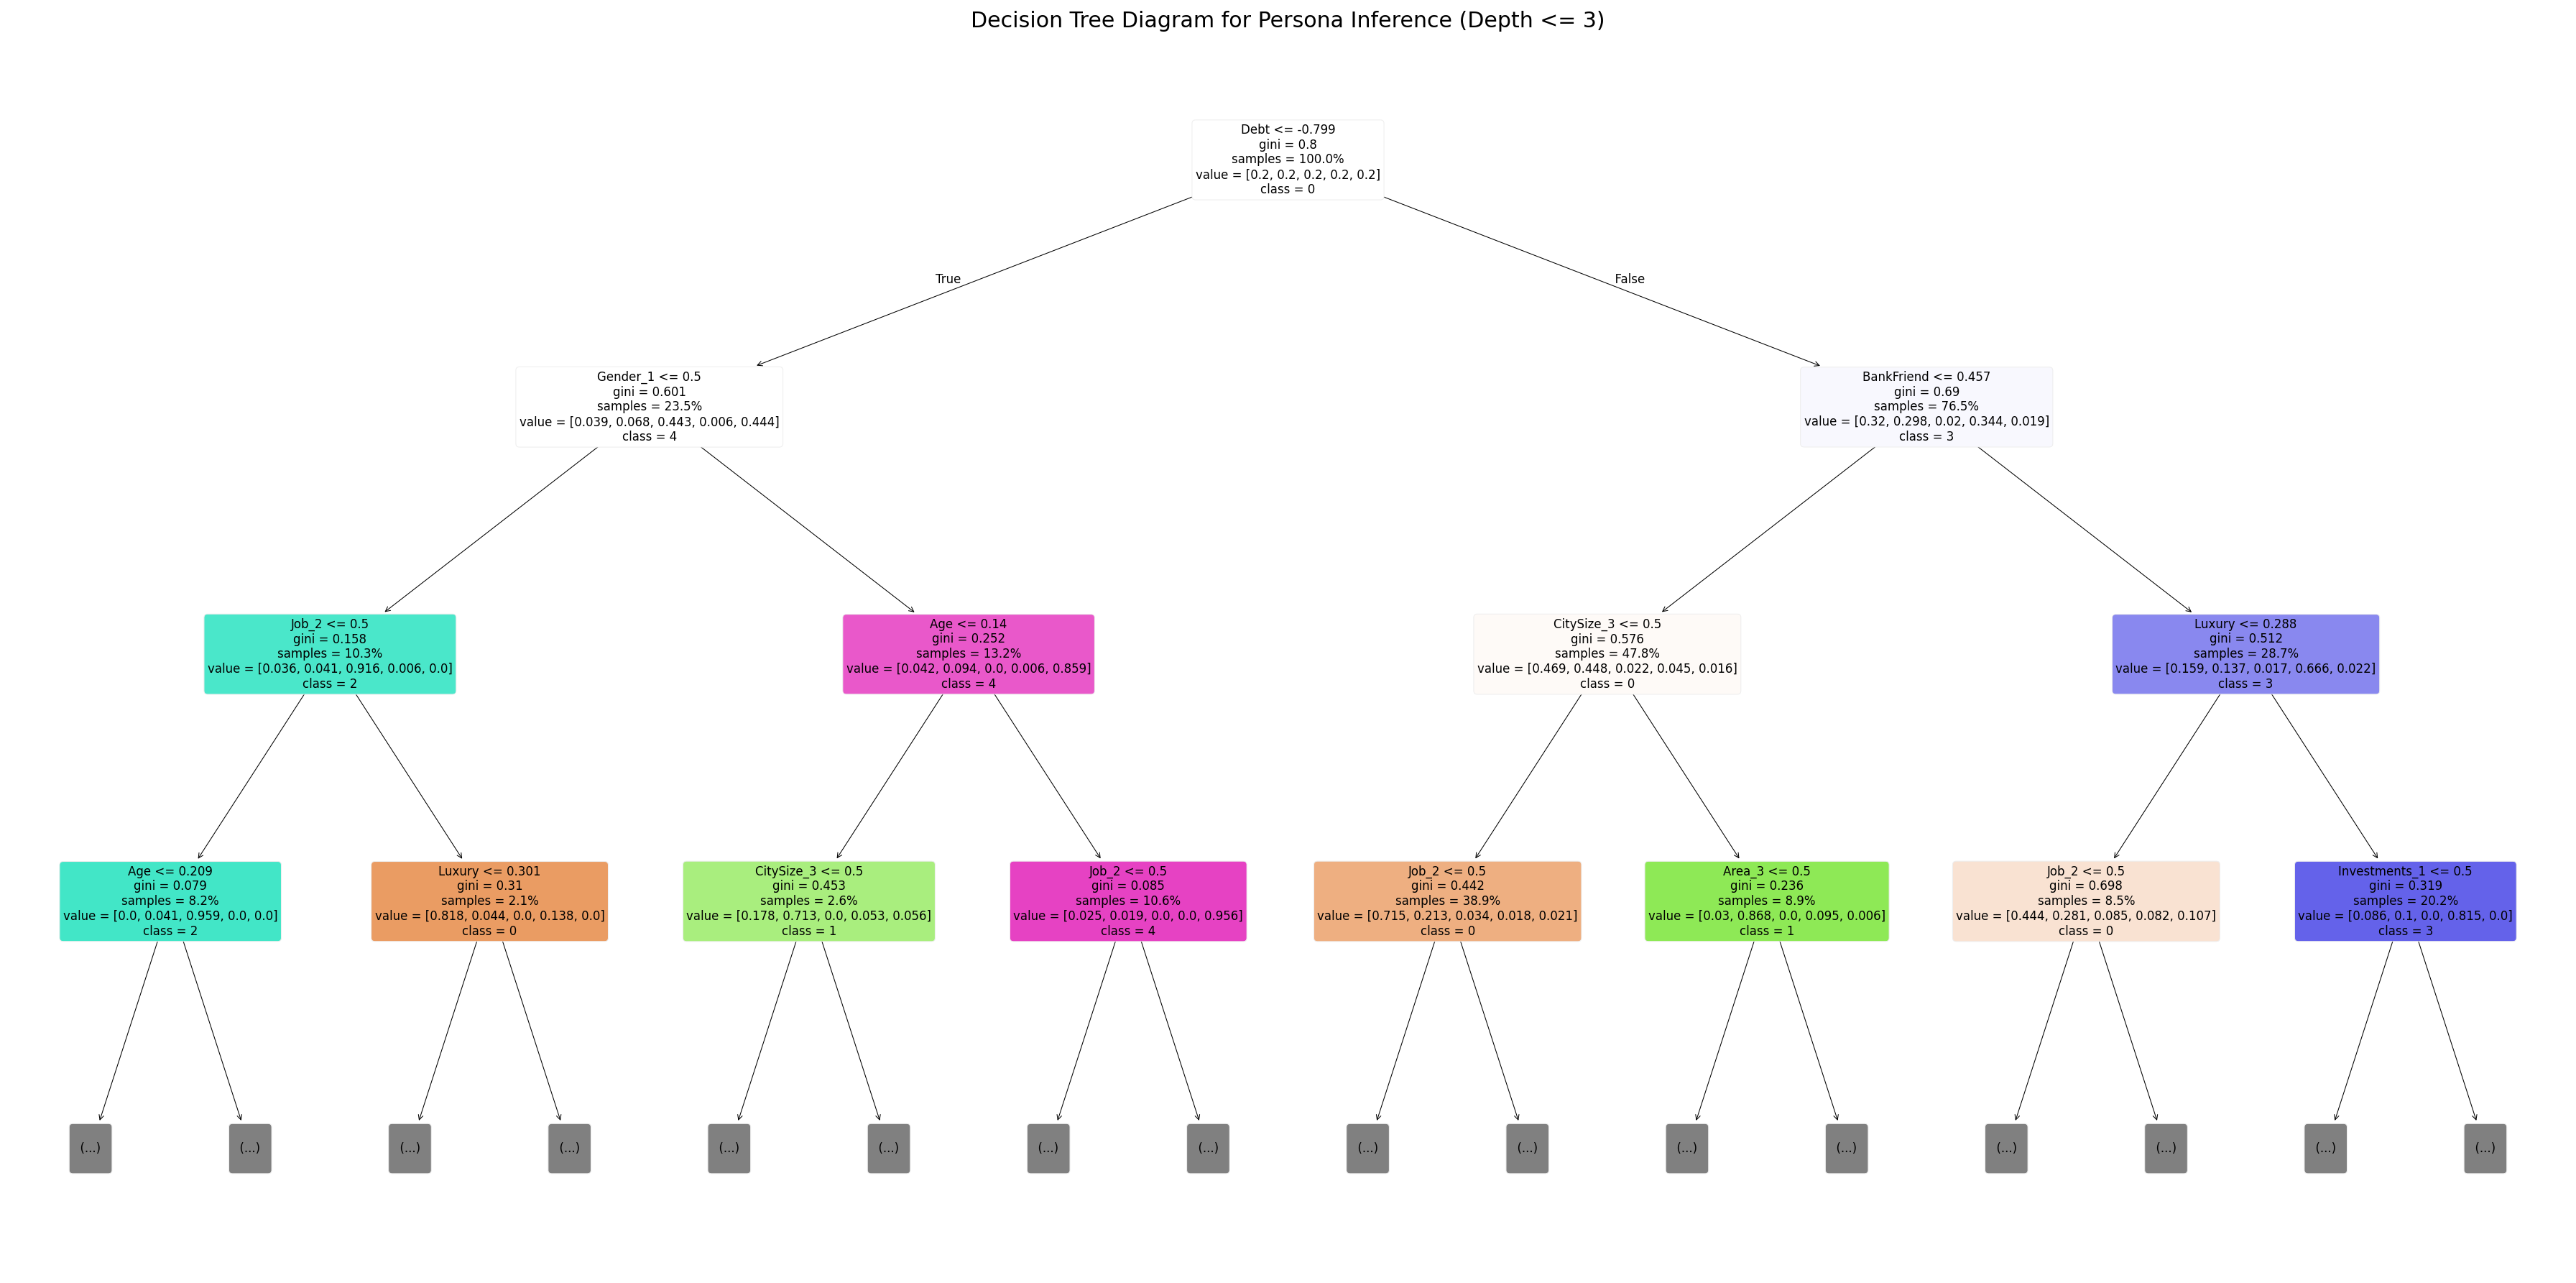

In [10]:
# Decision Tree diagram (limited depth for readability).
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=feature_order,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Diagram for Persona Inference (Depth <= 3)")
plt.tight_layout()
plt.savefig("result/persona_decision_tree_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

## 6) Prototype Interpretation and Visualization

Two complementary views are provided:

- A feature heatmap of the prototype signatures.
- A 2D PCA projection to compare customer points vs. learned prototypes.


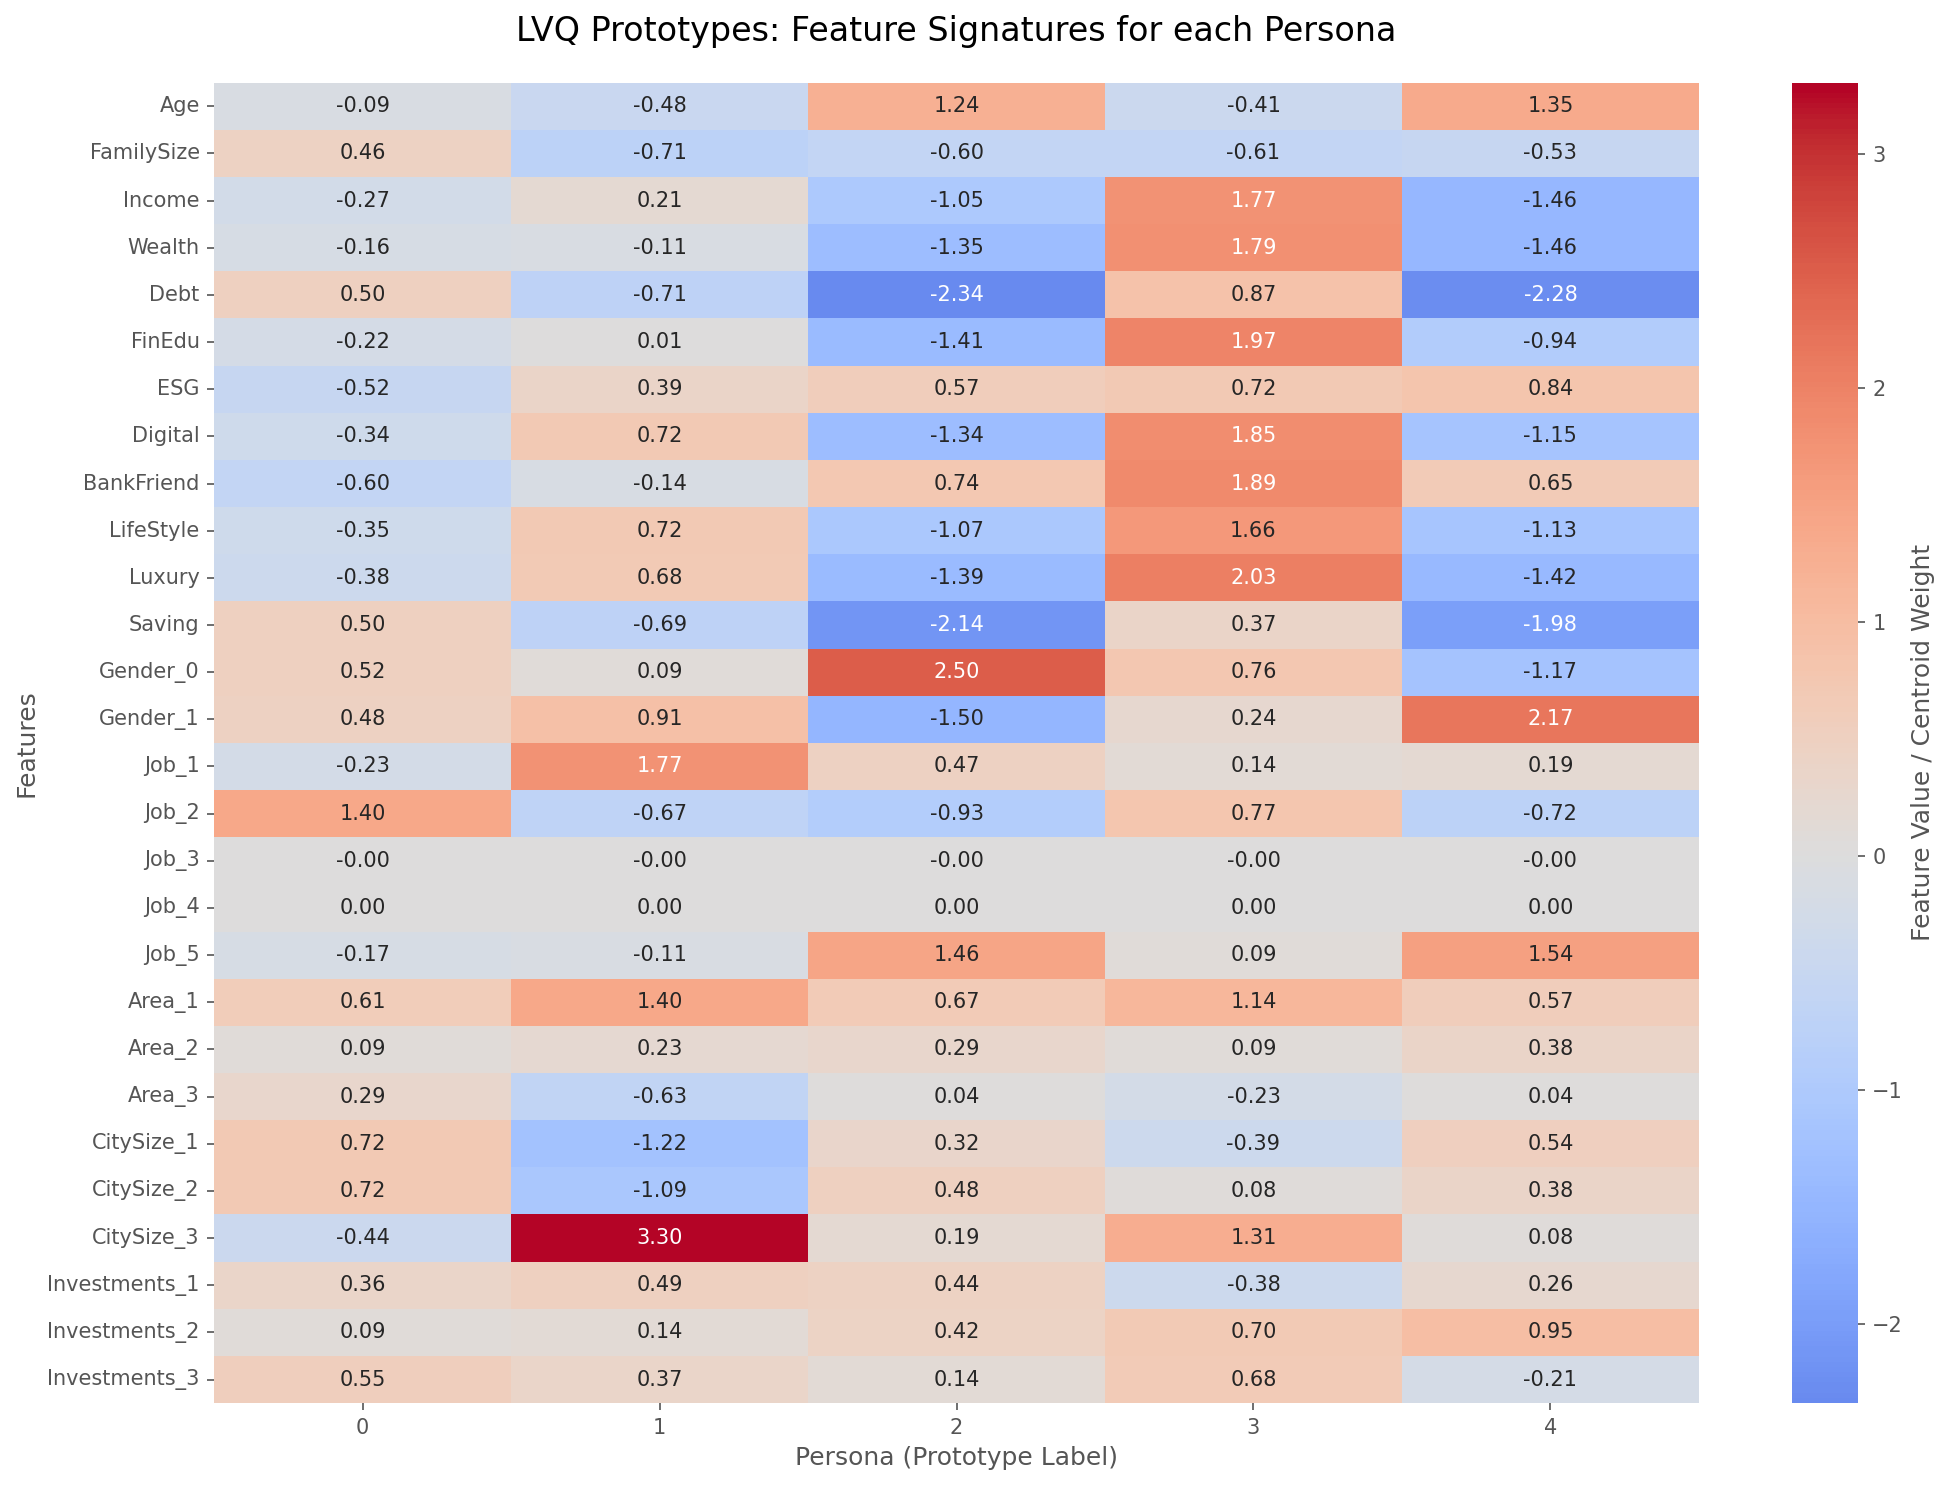

In [11]:
plt.figure(figsize=(14, 10))
heatmap_data = prototype_df.set_index("Prototype_Label").T
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Feature Value / Centroid Weight"},
)

plt.title("LVQ Prototypes: Feature Signatures for each Persona", fontsize=16, pad=20)
plt.xlabel("Persona (Prototype Label)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

/Users/pengrao/Workspace/Fintech/.venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


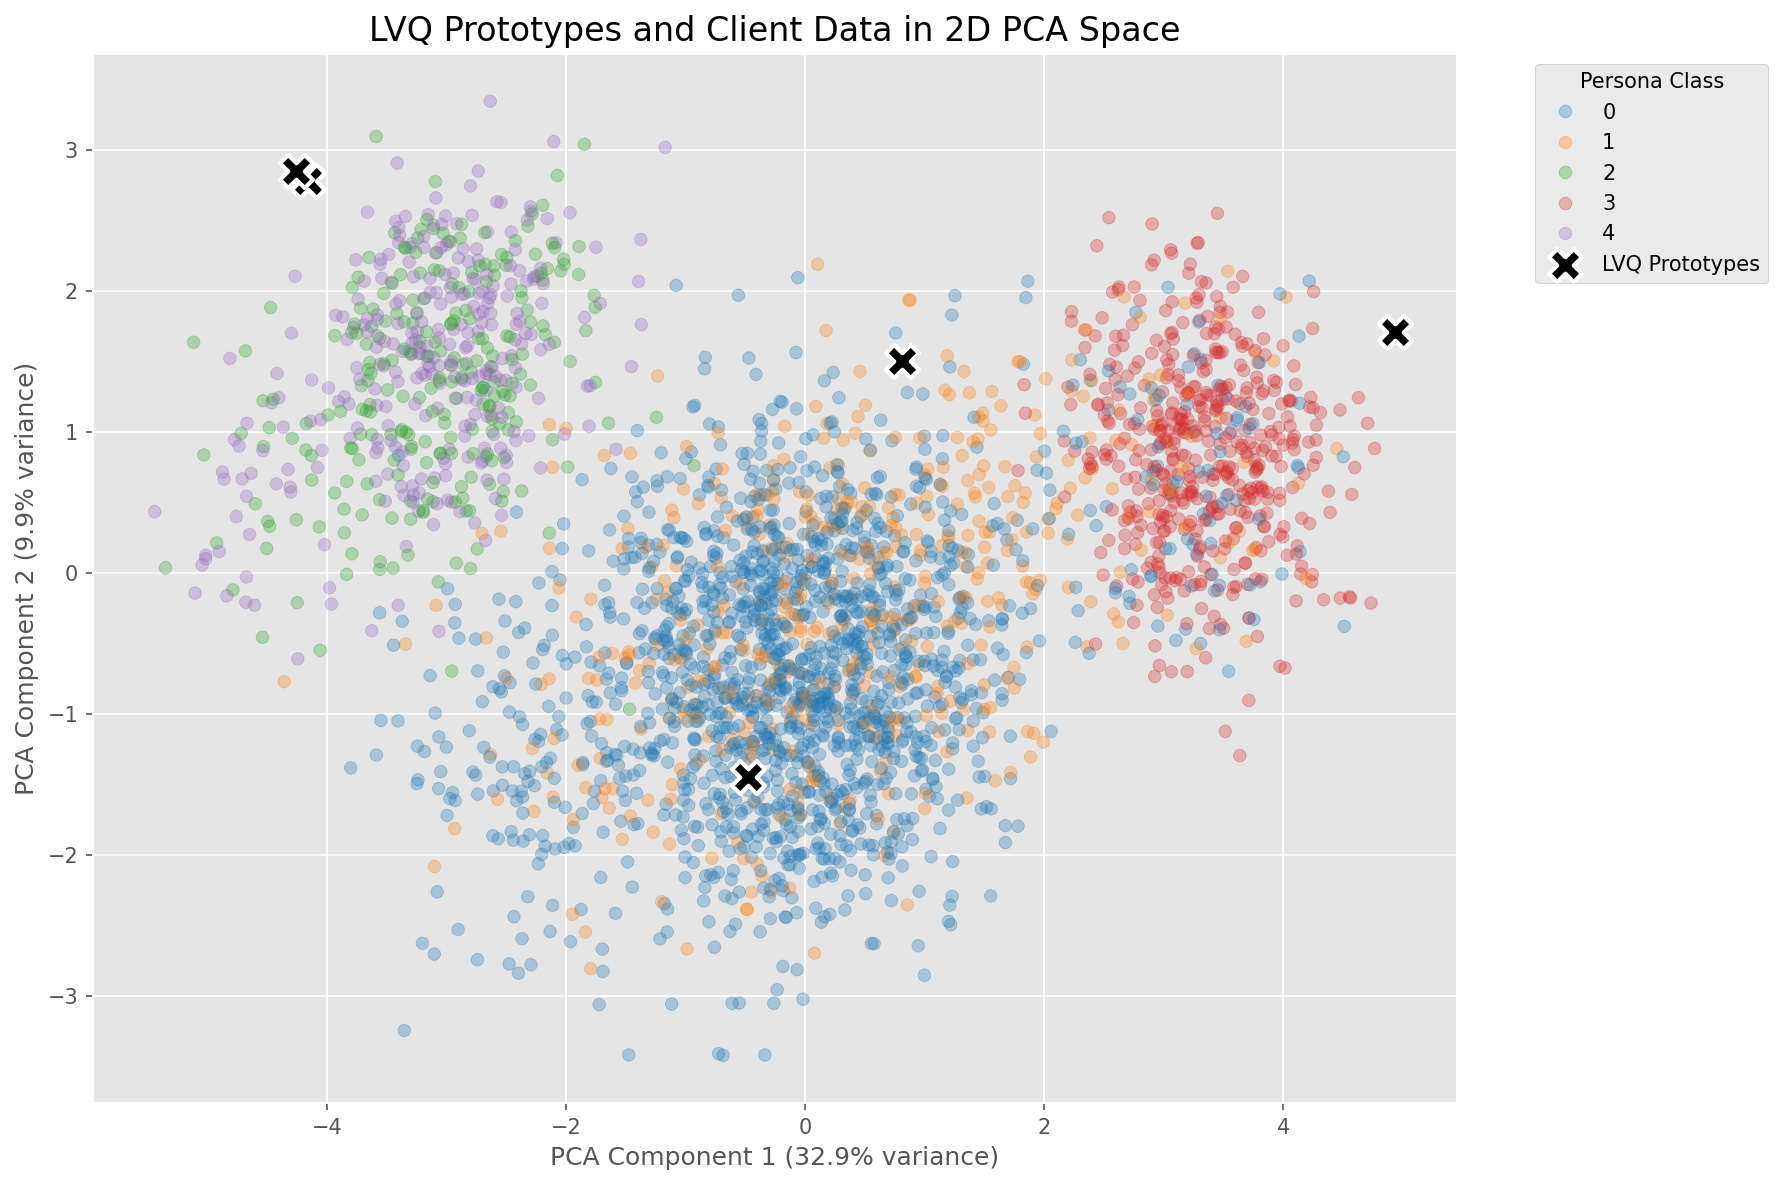

In [12]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
prototypes_pca = pca.transform(prototypes)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette="tab10",
    alpha=0.3,
    legend="full",
    edgecolor=None,
)

plt.scatter(
    prototypes_pca[:, 0],
    prototypes_pca[:, 1],
    c="black",
    marker="X",
    s=250,
    linewidths=2,
    edgecolors="white",
    label="LVQ Prototypes",
    zorder=5,
)

plt.title("LVQ Prototypes and Client Data in 2D PCA Space", fontsize=16)
plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Persona Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
prototype_df.to_csv("result/lvq_prototypes_interpreted.csv", index=False)
prototype_df

,Prototype_Label,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,0,-0.090627,0.456944,-0.266142,-0.162754,0.498390,-0.219626,-0.519630,-0.344352,-0.601145,...,-0.169114,0.611615,0.094265,0.294120,0.723614,0.719111,-0.442725,0.359926,0.087425,0.552649
1,1,-0.475131,-0.714487,0.213687,-0.105095,-0.705909,0.011761,0.392619,0.723312,-0.142157,...,-0.105233,1.396342,0.232170,-0.628515,-1.216119,-1.087232,3.303363,0.489518,0.143619,0.366872
2,2,1.235387,-0.601664,-1.047625,-1.354154,-2.338161,-1.408870,0.573051,-1.335143,0.740368,...,1.459318,0.668974,0.286392,0.044634,0.323521,0.484699,0.191781,0.443376,0.419888,0.136736
3,3,-0.409728,-0.608129,1.773684,1.785609,0.873702,1.966648,0.721570,1.846383,1.888835,...,0.086535,1.139873,0.092766,-0.232639,-0.385083,0.078130,1.306953,-0.377955,0.698853,0.679102
4,4,1.348670,-0.531007,-1.457628,-1.462825,-2.280020,-0.937308,0.835135,-1.152197,0.648009,...,1.535310,0.572258,0.384808,0.042934,0.542205,0.379731,0.078064,0.260220,0.950848,-0.211068
